Adding the necessary libraries

In [151]:
#!/usr/bin/env python3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

Loading video game sales data from github to a dataframe

In [112]:
url = "https://gist.githubusercontent.com/designernatan/27da044c6dc823f7ac7fe3a01f4513ed/raw/d15b5c7d7a5efb38750b16ec935fc126ec9a6e79/vgsales.csv"

videoGameData_df = pd.read_csv(url)

pd.set_option('display.width', None)
display(videoGameData_df.head(10))

#videoGameData_df.to_csv('videoGameData.csv')      #saving video game data to a csv as backup

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Exploratory Data Analysis

Looking at video games by platform

,Platform,count
0,DS,2163
1,PS2,2161
2,PS3,1329
3,Wii,1325
4,X360,1265
5,PSP,1213
6,PS,1196
7,PC,960
8,XB,824
9,GBA,822


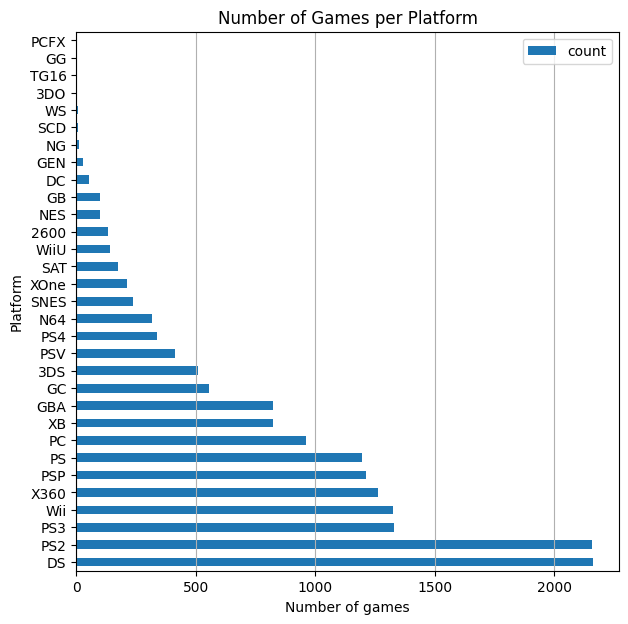

In [42]:
df = videoGameData_df['Platform'].value_counts().reset_index()
#df = df.to_frame()
display(df)
#print(df.columns.tolist())

df.plot(x='Platform', y='count', kind='barh', figsize=[7,7])
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

Looking at Game genre distribution overall

           Genre  count
0         Action   3316
1         Sports   2346
2           Misc   1739
3   Role-Playing   1488
4        Shooter   1310
5      Adventure   1286
6         Racing   1249
7       Platform    886
8     Simulation    867
9       Fighting    848
10      Strategy    681
11        Puzzle    582


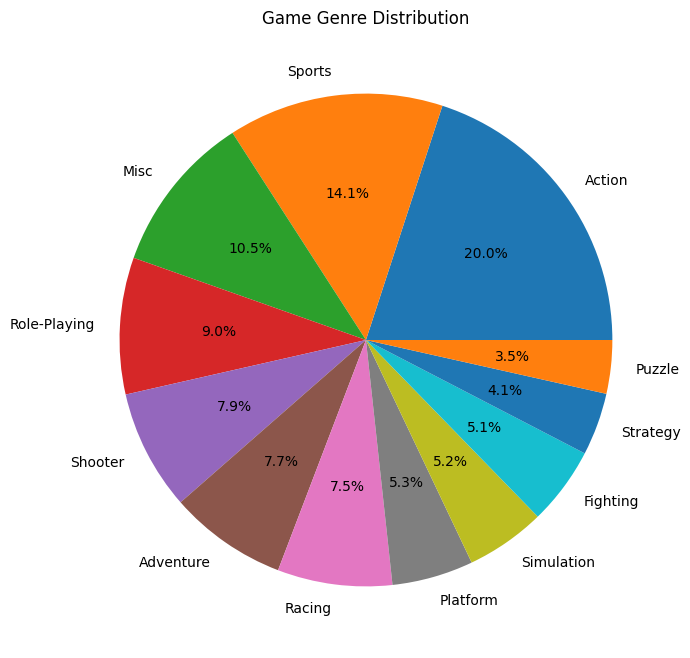

In [58]:
df = videoGameData_df['Genre'].value_counts().reset_index()
print(df)

df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title('Game Genre Distribution')
plt.show()

Looking at the platforms with the most and least games released

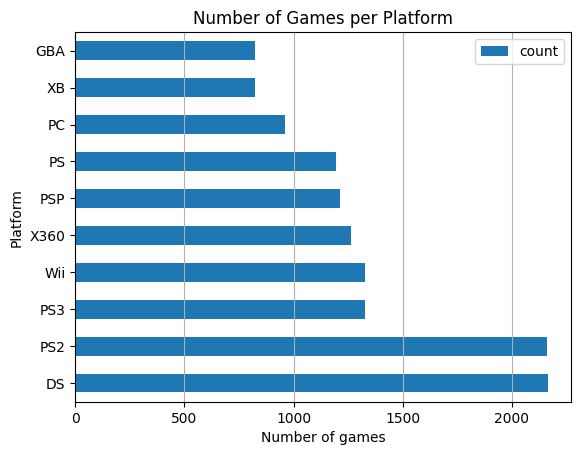

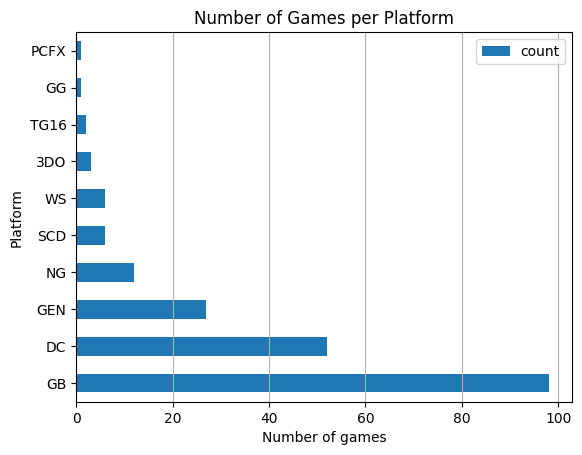

In [ ]:
df = videoGameData_df['Platform'].value_counts().reset_index()

dfMost = df.head(10)
dfMost.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

dfLeast = df.tail(10)
dfLeast.plot(x='Platform', y='count', kind='barh')
#plt.xticks(rotation=0, ha='right')
plt.xlabel(xlabel='Number of games')
plt.title('Number of Games per Platform')
plt.grid(axis='x')
plt.show()

Looking at video game genres for top 3 most popular platforms

DS


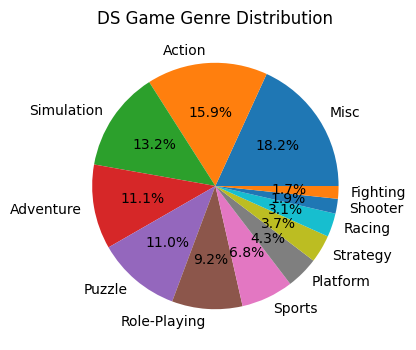

PS2


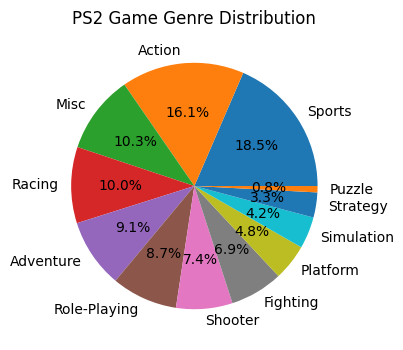

PS3


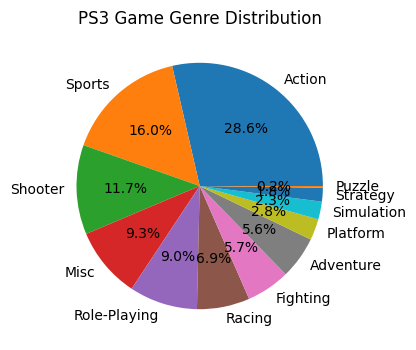

In [109]:
'''#print(dfMost['Platform'][0])
platform1 = dfMost['Platform'][0]   #getting name of platform with most games
print(platform1)

df = videoGameData_df[videoGameData_df['Platform']==platform1]['Genre'].value_counts().reset_index()    #getting count per genre for platform 1
#print(df)
df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(12,8), legend=False)
plt.ylabel('')
plt.title(platform1 + ' Game Genre Distribution')
plt.show()'''

df = videoGameData_df['Platform'].value_counts().reset_index()

counter = 0
while (counter<3): 
    platform = dfMost['Platform'][counter]   #getting name of platform with most games
    print(platform)

    df = videoGameData_df[videoGameData_df['Platform']==platform]['Genre'].value_counts().reset_index()    #getting count per genre for platform 1
    #print(df)
    df.plot(y='count', kind='pie', labels=df['Genre'], autopct='%1.1f%%', textprops={'fontsize': 10}, figsize=(4,4), legend=False)
    plt.ylabel('')
    plt.title(platform + ' Game Genre Distribution')
    plt.show()

    counter = counter + 1

Sales Trends per Year

Text(0, 0.5, 'Number of Games Sold')

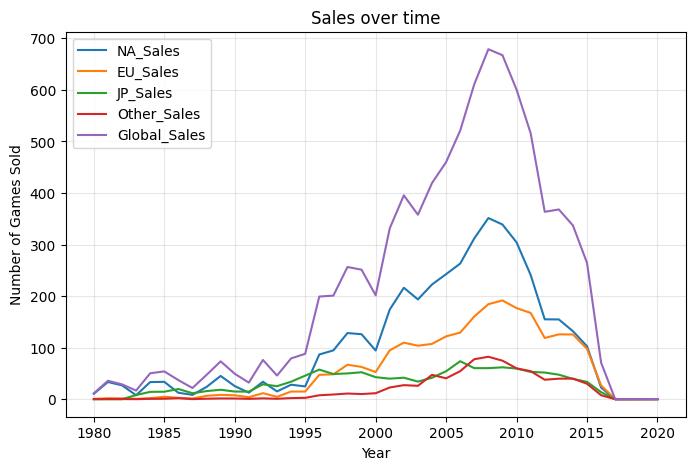

In [106]:
#df = videoGameData_df
'''df = videoGameData_df.groupby('Year')['NA_Sales'].sum().reset_index()
print(df.head(10))'''

df = videoGameData_df.groupby('Year').sum().reset_index()
#print(df.head(10))
#print(df.dtypes)

#fig, ax = plt.subplots(figsize=(8, 5))

fig, ax = plt.subplots(figsize=(8, 5))

#ax.plot(df['Platform'], df['NA_Sales'])
ax.plot(df['Year'], df['NA_Sales'], label='NA_Sales')
ax.plot(df['Year'], df['EU_Sales'], label='EU_Sales')
ax.plot(df['Year'], df['JP_Sales'], label='JP_Sales')
ax.plot(df['Year'], df['Other_Sales'], label='Other_Sales')
ax.plot(df['Year'], df['Global_Sales'], label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales over time')
ax.grid(alpha = 0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Games Sold')

Money per platform bar charts

"ax.bar(df['Platform'], df['NA_Sales'], label='NA_Sales')\nax.bar(df['Platform'], df['EU_Sales'], label='EU_Sales')\nax.bar(df['Platform'], df['JP_Sales'], label='JP_Sales')\nax.bar(df['Platform'], df['Other_Sales'], label='Other_Sales')\nax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales')"

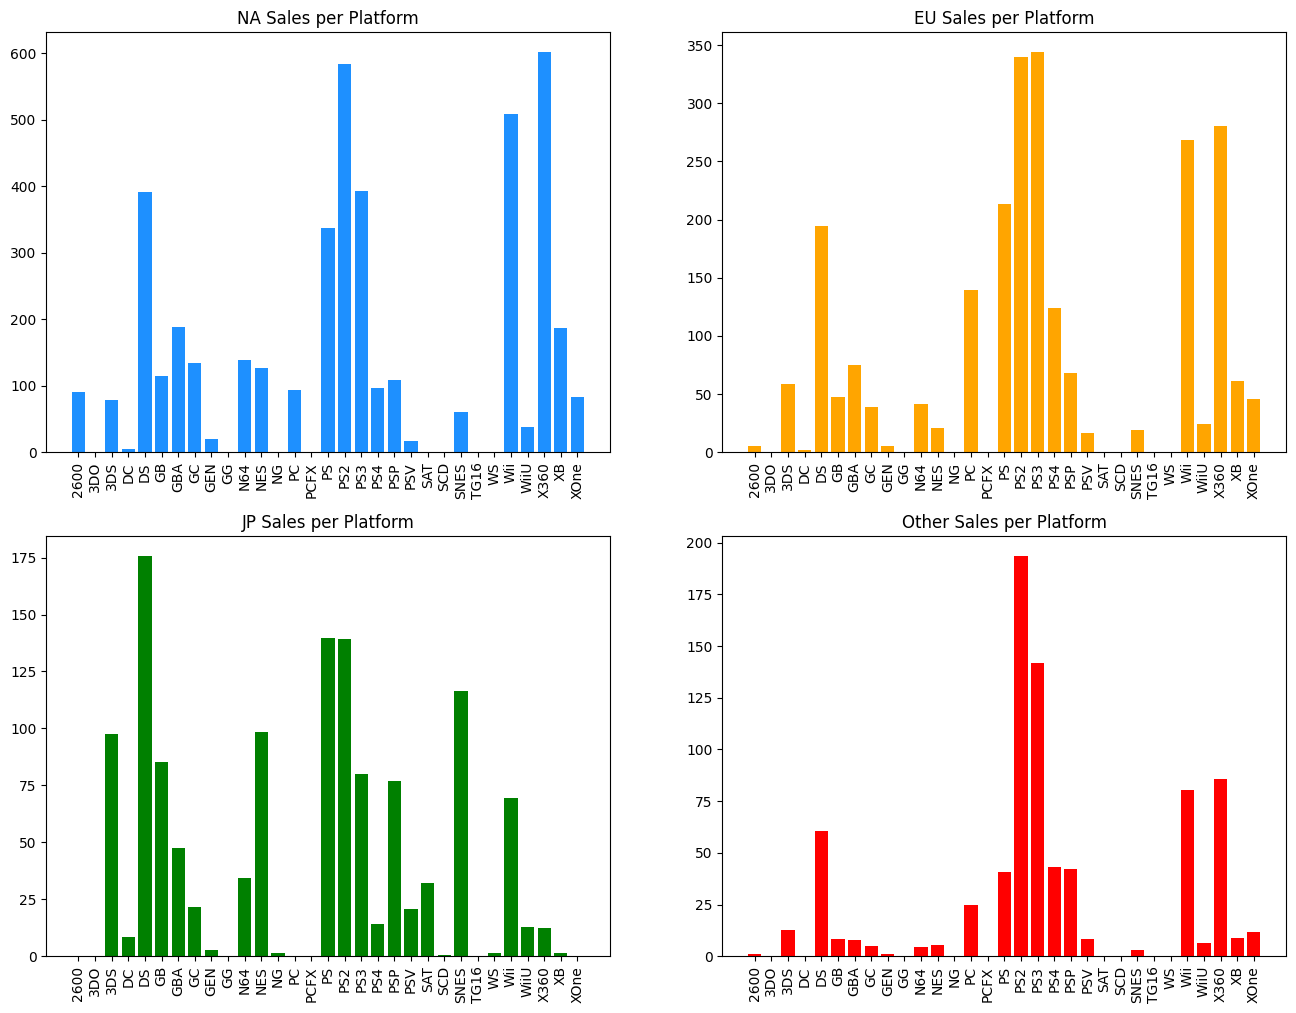

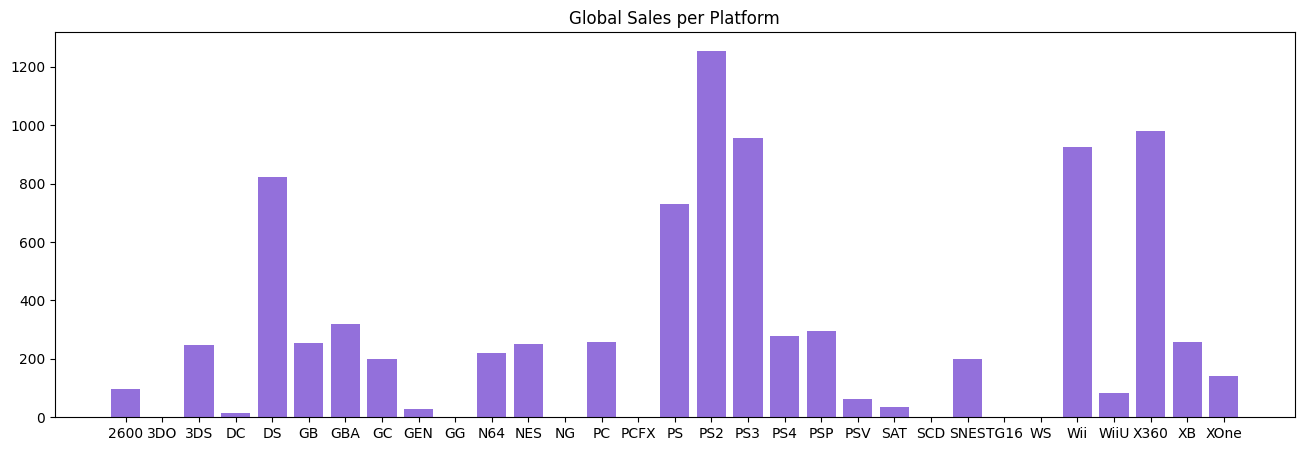

In [201]:
df = videoGameData_df.groupby('Platform').sum().reset_index()
#display(df.head(10))

fig, ax = plt.subplots(2, 2,figsize=(16, 12))

#print(len(df['Platform']))

ax[0,0].bar(df['Platform'], df['NA_Sales'], label='NA_Sales', color='dodgerblue',)
ax[0,0].set_title('NA Sales per Platform')
ax[0,1].bar(df['Platform'], df['EU_Sales'], label='EU_Sales', color='orange')
ax[0,1].set_title('EU Sales per Platform')
ax[1,0].bar(df['Platform'], df['JP_Sales'], label='JP_Sales', color='green')
ax[1,0].set_title('JP Sales per Platform')
ax[1,1].bar(df['Platform'], df['Other_Sales'], label='Other_Sales', color='red')
ax[1,1].set_title('Other Sales per Platform')

for axs in ax.flatten():
    #axs.tick_params(axis='x', labelsize=8)
    axs.tick_params(axis='x', rotation= 90)

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales', color='mediumpurple')
ax.set_title('Global Sales per Platform')

'''ax.bar(df['Platform'], df['NA_Sales'], label='NA_Sales')
ax.bar(df['Platform'], df['EU_Sales'], label='EU_Sales')
ax.bar(df['Platform'], df['JP_Sales'], label='JP_Sales')
ax.bar(df['Platform'], df['Other_Sales'], label='Other_Sales')
ax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales')'''

Money per platform grouped bar chart

"y = np.arange(len(df['Platform']))  \nheight = 1/5  \n\nfig, ax = plt.subplots(figsize=(5, 15))\n\nax.barh(y - 2*height, df['NA_Sales'], height, label='NA_Sales')\nax.barh(y - height, df['EU_Sales'], height, label='EU_Sales')\nax.barh(y, df['JP_Sales'], height, label='JP_Sales')\nax.barh(y + height, df['Other_Sales'], height, label='Other_Sales')\nax.barh(y + 2*height, df['Global_Sales'], height, label='Global_Sales')\n\nax.legend(loc='upper right')\nax.set_title('Sales per Platform')\nax.grid(alpha = 0.3)\nax.set_ylabel('Platform')\nax.set_xlabel('Number of Games Sold')\nax.set_yticks(y)\nax.set_yticklabels(df['Platform'])"

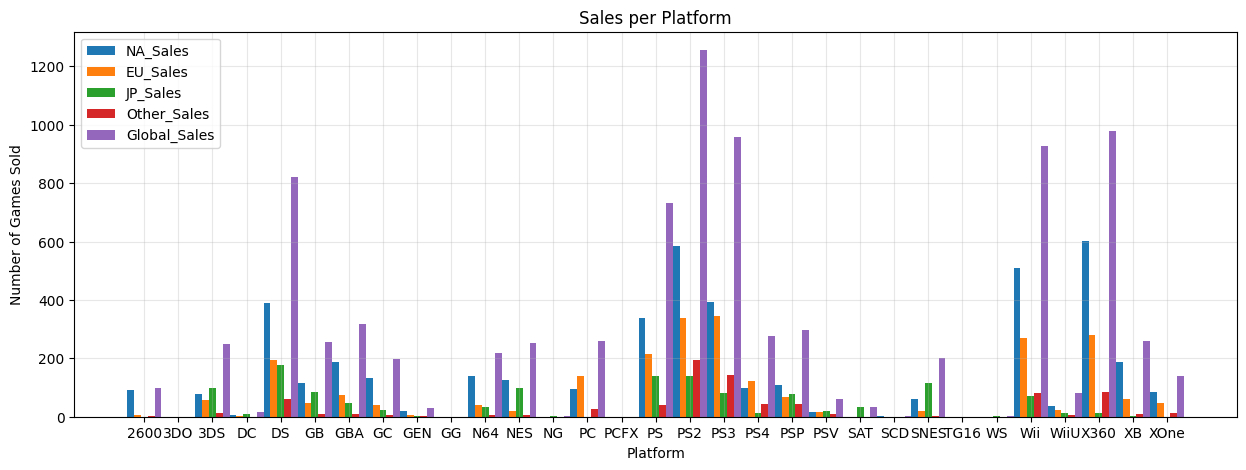

In [ ]:
df = videoGameData_df.groupby('Platform').sum().reset_index()
#display(df.head(10))

#fig, ax = plt.subplots(figsize=(8, 5))

#print(len(df['Platform']))

'''ax.bar(df['Platform'], df['NA_Sales'], label='NA_Sales')
ax.bar(df['Platform'], df['EU_Sales'], label='EU_Sales')
ax.bar(df['Platform'], df['JP_Sales'], label='JP_Sales')
ax.bar(df['Platform'], df['Other_Sales'], label='Other_Sales')
ax.bar(df['Platform'], df['Global_Sales'], label='Global_Sales')'''

x = np.arange(len(df['Platform']))  
width = 1/5  

fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(x - 2*width, df['NA_Sales'], width, label='NA_Sales')
ax.bar(x - width, df['EU_Sales'], width, label='EU_Sales')
ax.bar(x, df['JP_Sales'], width, label='JP_Sales')
ax.bar(x + width, df['Other_Sales'], width, label='Other_Sales')
ax.bar(x + 2*width, df['Global_Sales'], width, label='Global_Sales')

ax.legend(loc='upper left')
ax.set_title('Sales per Platform')
ax.grid(alpha = 0.3)
ax.set_xlabel('Platform')
ax.set_ylabel('Number of Games Sold')
ax.set_xticks(np.arange(0, len(df['Platform']), 1))
ax.set_xticklabels(df['Platform'])
#ax.xaxis.set_major_locator(ticker.MultipleLocator(1))


'''y = np.arange(len(df['Platform']))  
height = 1/5  

fig, ax = plt.subplots(figsize=(5, 15))

ax.barh(y - 2*height, df['NA_Sales'], height, label='NA_Sales')
ax.barh(y - height, df['EU_Sales'], height, label='EU_Sales')
ax.barh(y, df['JP_Sales'], height, label='JP_Sales')
ax.barh(y + height, df['Other_Sales'], height, label='Other_Sales')
ax.barh(y + 2*height, df['Global_Sales'], height, label='Global_Sales')

ax.legend(loc='upper right')
ax.set_title('Sales per Platform')
ax.grid(alpha = 0.3)
ax.set_ylabel('Platform')
ax.set_xlabel('Number of Games Sold')
ax.set_yticks(y)
ax.set_yticklabels(df['Platform'])'''

Top 10 Publishers with the Most Global Sales

In [226]:
'''df = videoGameData_df['Publisher'].value_counts().reset_index()
pd.set_option('display.max_rows', None)
display(df.head(10))'''

df = videoGameData_df.groupby('Publisher').sum().reset_index()
'''pd.set_option('display.max_rows', None)
display(df.head(10))'''

df= df.sort_values(by=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'], ascending=False).head(10).reset_index()
df = df[['Publisher','NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]
display(df.head(10))


,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Nintendo,816.87,418.74,455.42,95.33,1786.56
1,Electronic Arts,595.07,371.27,14.04,129.77,1110.32
2,Activision,429.70,215.53,6.54,75.34,727.46
3,Sony Computer Entertainment,265.22,187.72,74.10,80.45,607.50
4,Ubisoft,253.43,163.32,7.50,50.26,474.72
5,Take-Two Interactive,220.49,118.14,5.83,55.24,399.54
6,THQ,208.77,94.73,5.01,32.14,340.77
7,Microsoft Game Studios,155.35,68.61,3.26,18.56,245.79
8,Atari,110.04,27.12,10.71,9.01,157.22
9,Sega,109.40,82.00,57.03,24.52,272.99
